In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import h5py

In [54]:
from rc import ESN, ESNConfig

In [55]:

with h5py.File('../data_eigenworm/crawl.mat', 'r') as f:
    tr_refs = f['tr'][1]
    print(f"tr shape: {tr_refs.shape}")
    
    tr_data = []
    for ref in tr_refs.flatten():
        data = f[ref][:]
        tr_data.append(data)
        print(f"Data shape: {data.shape}")


tr shape: (1,)
Data shape: (5, 33600)


In [4]:
def filter_nans(pcs):
    nan_mask = np.isnan(pcs).any(axis=0)
    
    valid_indices = np.where(~nan_mask)[0]
    
    indexes_to_skip = []
    for i in range(1, len(valid_indices)):
        if valid_indices[i] - valid_indices[i-1] > 1:
            indexes_to_skip.append(i)
    
    filtered_pcs = pcs[:, ~nan_mask]
    
    return filtered_pcs, indexes_to_skip
all_pcs = []
all_skip_indices = [] 
current_index = 0

for i in range(len(tr_data)):  
    filtered_pcs, gap_indices = filter_nans(tr_data[i][:5, :])
    
    for idx in gap_indices:
        all_skip_indices.append(idx + current_index)
    
    all_pcs.append(filtered_pcs)
    current_index += filtered_pcs.shape[1]
    
    if i < len(tr_data) - 1:
        all_skip_indices.append(current_index)

all_pcs = np.hstack(all_pcs)

In [5]:
worm_N2_scaled = StandardScaler().fit_transform(all_pcs.T).T

In [6]:
dt = 1/16

In [7]:
config = ESNConfig(
    N=10000,
    input_dim=5,
    spectral_radius=0.1809616855907689,
    alpha=1.5,
    sparsity=0.99,
    input_scaling=1.2665236214415563,
    bias_scaling=0.01,
    seed=None,
    mode='leaky',
    leaky_rate=0.7057809844406092,
)

In [8]:
config

ESNConfig(N=10000, input_dim=5, spectral_radius=0.1809616855907689, alpha=1.5, sparsity=0.99, input_scaling=1.2665236214415563, bias_scaling=0.01, seed=None, weights_generation_strategy='Gaussian', bias_generation_strategy='Uniform', input_generation_strategy='Uniform', self_connections=False, dtype=dtype('float64'), mode='leaky', leaky_rate=0.7057809844406092, beta=0.5, scale=0.1)

In [9]:
worm_N2_scaled_resampled = worm_N2_scaled[:, ::2]

In [10]:
inputdim = 5


In [25]:
esn = ESN(config)
esn.train(worm_N2_scaled[:inputdim, :], washout=2000)


In [41]:
esn_resampled = ESN.load("/Users/iliasoroka/RC/esn_resampled.pkl.npz")

In [45]:
esn_resampled.train(worm_N2_scaled_resampled[:inputdim, :], washout=2000)


In [47]:
warmup_data_resampled = worm_N2_scaled_resampled[:inputdim, :2000]
predictions, states = esn_resampled.predict(warmup_data_resampled, steps=5000)

In [56]:
warmup_data = worm_N2_scaled[:inputdim, 2000:4000]
predictions, states = esn.predict(warmup_data, steps=10000)

KeyboardInterrupt: 

In [27]:
read_data_slice = worm_N2_scaled[:inputdim, 4000:14000]

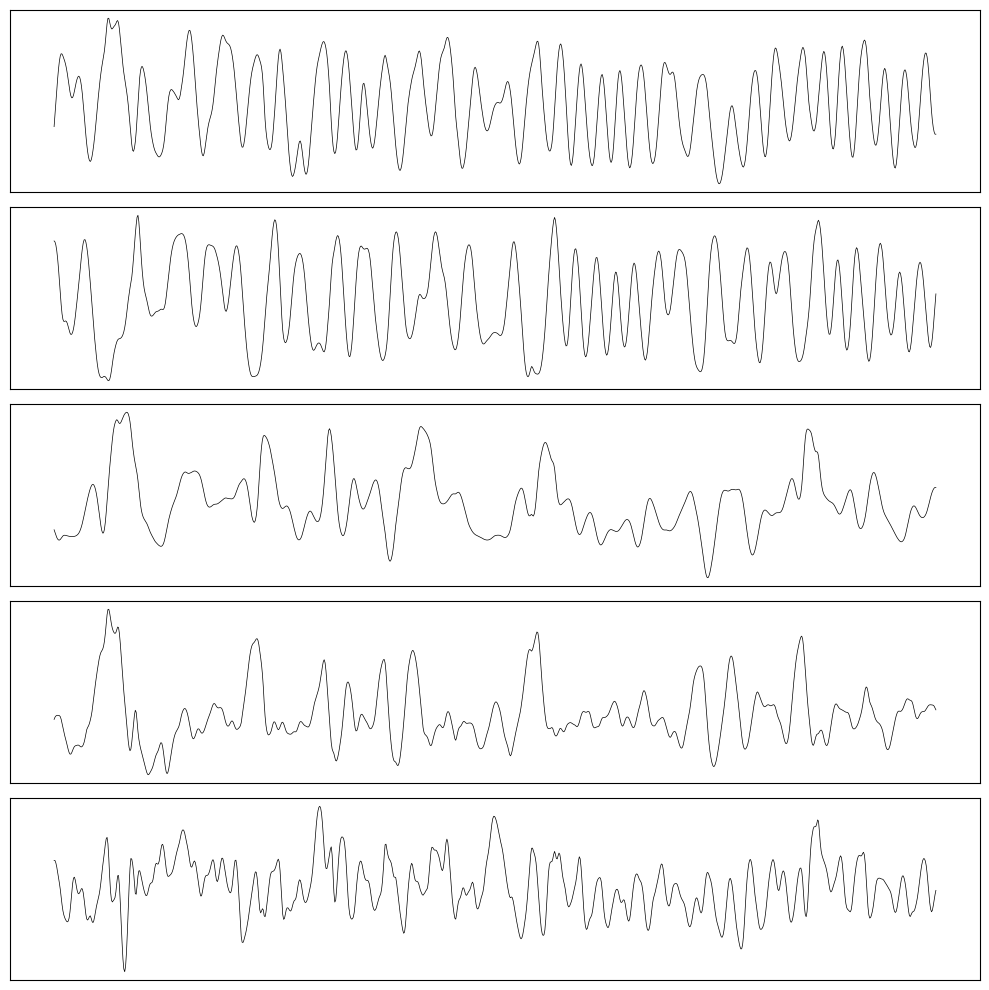

In [28]:
fig, axes = plt.subplots(5, 1, figsize=(10, 10))

for i in range(5):
    axes[i].plot(read_data_slice[i, :1000], linewidth=0.5, color='black')
    # axes[i].set_ylabel(f'Dim {i}')
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('read_data_slice.svg', format='svg', transparent=True)
plt.savefig('read_data_slice.pdf', format='pdf', bbox_inches='tight')
plt.show()


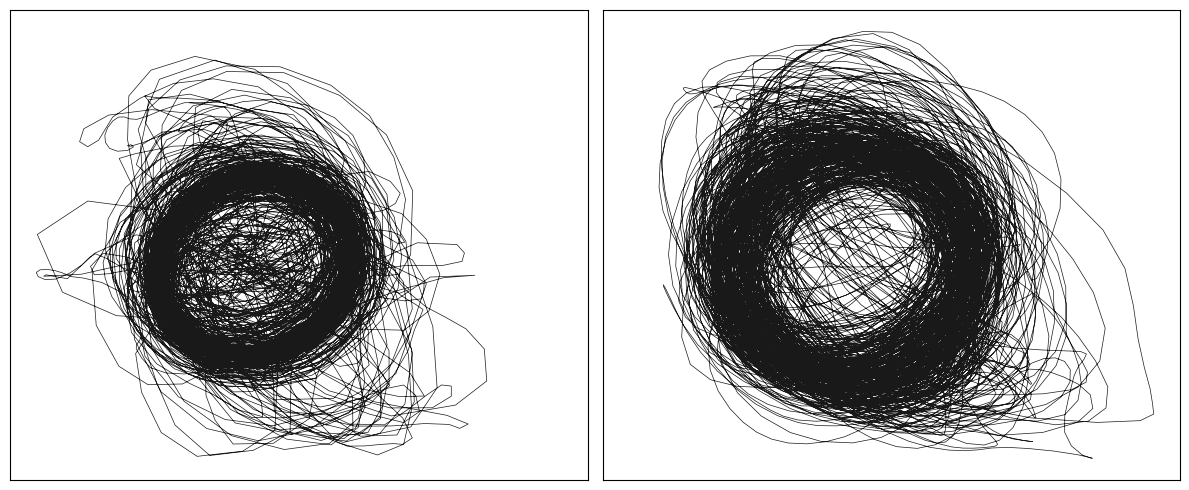

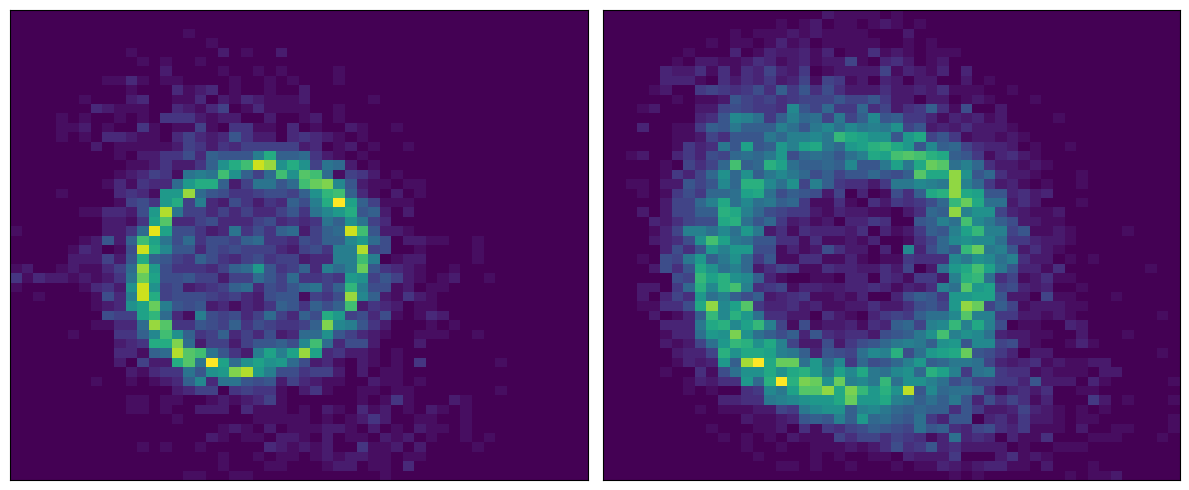

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_min = min(predictions[0, :].min(), read_data_slice[0, :].min())
x_max = max(predictions[0, :].max(), read_data_slice[0, :].max())
y_min = min(predictions[1, :].min(), read_data_slice[1, :].min())
y_max = max(predictions[1, :].max(), read_data_slice[1, :].max())

x_padding = (x_max - x_min) * 0.05
y_padding = (y_max - y_min) * 0.05

ax1.plot(predictions[0, :], predictions[1, :], 'black', linewidth=0.5, alpha=0.9)

ax1.set_xlim(x_min - x_padding, x_max + x_padding)
ax1.set_ylim(y_min - y_padding, y_max + y_padding)
ax1.set_xticks([])
ax1.set_yticks([])

ax2.plot(read_data_slice[0, :], read_data_slice[1, :], 'black', linewidth=0.5, alpha=0.9)

ax2.set_xlim(x_min - x_padding, x_max + x_padding)
ax2.set_ylim(y_min - y_padding, y_max + y_padding)
ax2.set_xticks([])
ax2.set_yticks([])

plt.tight_layout()
# plt.savefig('prediction_vs_real.svg', format='svg', transparent=True)
# plt.savefig('prediction_vs_real.pdf', format='pdf', bbox_inches='tight')
plt.show()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_min = min(predictions[0, :].min(), read_data_slice[0, :].min())
x_max = max(predictions[0, :].max(), read_data_slice[0, :].max())
y_min = min(predictions[1, :].min(), read_data_slice[1, :].min())
y_max = max(predictions[1, :].max(), read_data_slice[1, :].max())

ax1.hist2d(predictions[0, :], predictions[1, :], bins=50, range=[[x_min, x_max], [y_min, y_max]])
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.set_xticks([])
ax1.set_yticks([])

ax2.hist2d(read_data_slice[0, :], read_data_slice[1, :], bins=50, range=[[x_min, x_max], [y_min, y_max]])
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.set_xticks([])
ax2.set_yticks([])

plt.tight_layout()
# plt.savefig('histogram_prediction.svg', format='svg', transparent=True)
# plt.savefig('histogram_real.svg', format='svg', transparent=True)
plt.show()

In [ ]:
spectrum = esn.lyapunov_spectrum(worm_N2_scaled[:inputdim, 2000:], 20, 2500, 2, 1/16, 2, 2000, 500, False)

In [ ]:
spectrum

{'mean': array([ 8.56255326e-01,  3.07836146e-01, -4.12316984e-03, -3.09898964e-01,
        -7.06327104e-01, -1.26471626e+00, -1.95729694e+00, -2.79252918e+00,
        -3.78587062e+00, -5.03049132e+00, -6.62086857e+00, -7.30064991e+00,
        -7.76026677e+00, -1.14169728e+01, -1.36583128e+01, -1.62711712e+01,
        -1.62953625e+01, -1.63057897e+01, -1.63141052e+01, -1.63202879e+01]),
 'std': array([0.00798266, 0.03331637, 0.05969548, 0.04212458, 0.00104063,
        0.08657517, 0.19082428, 0.16346594, 0.294512  , 0.44905723,
        0.41429783, 0.4083539 , 0.43181115, 0.28243949, 0.19246334,
        0.0722459 , 0.0538368 , 0.06174177, 0.06497932, 0.06430509]),
 'all_samples': array([[  0.84827266,   0.34115252,   0.05557231,  -0.35202354,
          -0.70528647,  -1.35129143,  -2.14812122,  -2.95599512,
          -4.08038262,  -5.47954855,  -7.0351664 ,  -7.70900381,
          -8.19207792, -11.6994123 , -13.85077618, -16.34341709,
         -16.34919925, -16.36753144, -16.3790845 , -16

In [50]:
spectrum_resampled = esn_resampled.lyapunov_spectrum(worm_N2_scaled_resampled[:inputdim, 2000:], 20, 2500, 1, 2/16, 1, 2000, 500, False)

In [51]:
spectrum_resampled

{'mean': array([ 0.56900337,  0.22704113, -0.02586114, -0.28691018, -0.509014  ,
        -0.76446489, -1.16272335, -1.51790428, -1.90907088, -2.20357229,
        -2.85641229, -3.12996796, -3.67355338, -4.18683869, -6.10430232,
        -7.98370935, -7.99739876, -7.99784802, -8.00400365, -8.00580594]),
 'std': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 'all_samples': array([[ 0.56900337,  0.22704113, -0.02586114, -0.28691018, -0.509014  ,
         -0.76446489, -1.16272335, -1.51790428, -1.90907088, -2.20357229,
         -2.85641229, -3.12996796, -3.67355338, -4.18683869, -6.10430232,
         -7.98370935, -7.99739876, -7.99784802, -8.00400365, -8.00580594]]),
 'convergence': [],
 'num_valid_samples': 1,
 'max_lyapunov': np.float64(0.5690033701811626),
 'distances': [np.float64(0.3013511446021335)]}

In [2]:
import pickle

with open('/Users/iliasoroka/ReservoirComputing/results_data/spectrum.pkl', 'rb') as f:
    spectrum_1 = pickle.load(f)

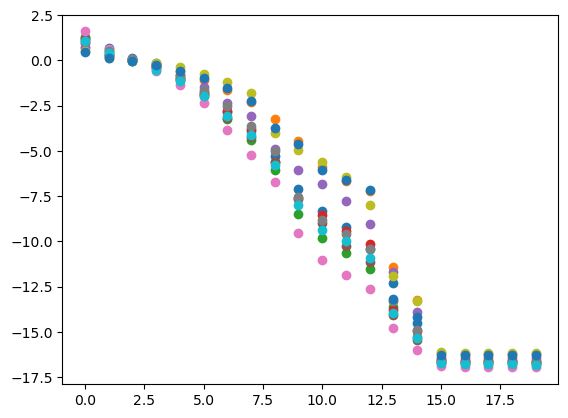

In [195]:
plt.plot(spectrum['mean'], 'o')
plt.plot(spectrum_1['mean'], 'o')
plt.plot(spectrum_2['mean'], 'o')
plt.plot(spectrum_3['mean'], 'o')
plt.plot(spectrum_4['mean'], 'o')
plt.plot(spectrum_6['all_samples'][1], 'o')
plt.plot(spectrum_7['mean'], 'o')
plt.plot(spectrum_8['mean'], 'o')
plt.plot(spectrum_9['mean'], 'o')
plt.plot(spectrum_10['all_samples'][1], 'o')
plt.plot(spectrum_11['mean'], 'o')
plt.show()

In [ ]:
import pickle

spectra_list = [
    spectrum,
    spectrum_1,
    spectrum_2,
    spectrum_3,
    spectrum_4,
    spectrum_6,
    spectrum_7,
    spectrum_8,
    spectrum_9,
    spectrum_10,
    spectrum_11,
]

with open('/Users/iliasoroka/ReservoirComputing/spectra_list.pkl', 'wb') as f:
    pickle.dump(spectra_list, f)


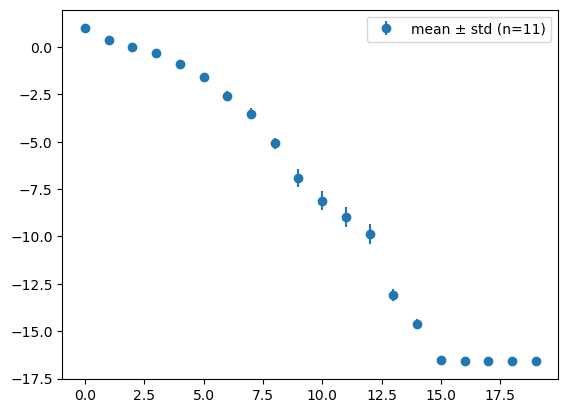

In [ ]:
import numpy as np

means_list = [
    spectrum['mean'],
    spectrum_1['mean'],
    spectrum_2['mean'],
    spectrum_3['mean'],
    spectrum_4['mean'],
    spectrum_6['all_samples'][1],
    spectrum_7['mean'],
    spectrum_8['mean'],
    spectrum_9['mean'],
    spectrum_10['all_samples'][1],
    spectrum_11['mean'],
]

means_arr = np.vstack(means_list)
mean_of_means = np.mean(means_arr, axis=0)
std_of_means = np.std(means_arr, axis=0)

plt.errorbar(
    np.arange(len(mean_of_means)),
    mean_of_means,
    yerr=std_of_means/np.sqrt(11),
    fmt='o',
    label='mean ± std '
)

plt.legend()
plt.show()

In [ ]:
lyap_exponents = spectrum['mean']
cumulative_sum = 0
j = -1

for i, exp in enumerate(lyap_exponents):
    cumulative_sum += exp
    if cumulative_sum >= 0:
        j = i
    else:
        break

if j >= 0 and j < len(lyap_exponents) - 1:
    sum_up_to_j = np.sum(lyap_exponents[:j+1])
    ky_dimension = j + 1 + sum_up_to_j / abs(lyap_exponents[j + 1])
elif j >= 0:
    ky_dimension = j + 1
else:
    ky_dimension = 0

print(f"Kaplan-Yorke dimension: {ky_dimension}")
ky_dimension

Kaplan-Yorke dimension: 6.279498994680238


np.float64(6.279498994680238)

In [127]:
conditional_lyapunov_spectrum

{'exponents': array([-7.84495696]),
 'convergence': None,
 'max_cle': np.float64(-7.844956962748173),
 'sum_cle': np.float64(-7.844956962748173),
 'num_renorms': 13685}

In [111]:
esn_resampled.save('esn_resampled.pkl')

In [ ]:
with open('spectrum.pkl', 'wb') as f:
    pickle.dump(spectrum, f)

spectrum

{'mean': array([ 7.08974610e-01,  2.42320109e-01,  4.05161052e-03, -2.15099287e-01,
        -5.87733678e-01, -1.07464417e+00, -1.65300763e+00, -2.31251915e+00,
        -3.23787708e+00, -4.47262878e+00, -5.90416130e+00, -6.65752845e+00,
        -7.19350984e+00, -1.14326151e+01, -1.32602250e+01, -1.61875325e+01,
        -1.62008310e+01, -1.62122037e+01, -1.62132207e+01, -1.62194188e+01]),
 'std': array([0.10424236, 0.07686225, 0.02803245, 0.06006936, 0.05924392,
        0.07808707, 0.14271411, 0.13930264, 0.23094478, 0.31742409,
        0.21069004, 0.29175432, 0.32616875, 0.1806267 , 0.1397625 ,
        0.03687436, 0.03512281, 0.03546906, 0.03798476, 0.03897983]),
 'all_samples': array([[ 7.97029719e-01,  3.22324877e-01, -1.54959764e-02,
         -2.48776377e-01, -6.39409347e-01, -1.07996660e+00,
         -1.83200487e+00, -2.40158850e+00, -3.50521394e+00,
         -4.50339021e+00, -5.94382269e+00, -6.83798227e+00,
         -7.33018973e+00, -1.14854848e+01, -1.33495761e+01,
         -1.61

In [112]:
with open('spectrum_resampled.pkl', 'wb') as f:
    pickle.dump(spectrum_resampled, f)


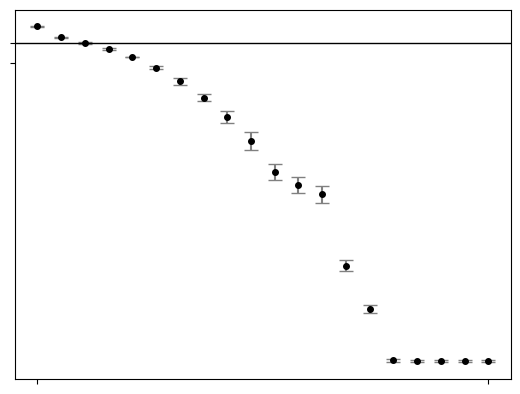

In [34]:
plt.figure()

all_samples = spectrum_11['all_samples']
median_lyapunov = np.median(all_samples, axis=0)

n_bootstraps = 1000
bootstrap_medians = []
for _ in range(n_bootstraps):
    resample_idxs = np.random.choice(len(all_samples), len(all_samples), replace=True)
    resample = all_samples[resample_idxs]
    bootstrap_medians.append(np.median(resample, axis=0))

bootstrap_medians = np.array(bootstrap_medians)
ci_lower = np.percentile(bootstrap_medians, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_medians, 97.5, axis=0)
yerr = np.array([median_lyapunov - ci_lower, ci_upper - median_lyapunov])

img = plt.errorbar(range(1, len(median_lyapunov) + 1), median_lyapunov,
                   yerr=yerr, fmt='k.', ms=8, capsize=5, 
                   ecolor='gray')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.xticks([1, len(median_lyapunov)], ['', ''])
plt.yticks([0, -1], ['', ''])
plt.minorticks_off()
plt.savefig('lyapunov_spectrum.svg', format='svg', transparent=True)
plt.savefig('lyapunov_spectrum.pdf', format='pdf', bbox_inches='tight')
plt.show()

plt.show()

In [35]:
for mean, lower, upper in zip(median_lyapunov, ci_lower, ci_upper):
    print(lower,mean, upper)

0.8482726617017299 0.8562553263668908 0.8642379910320517
0.2745197767123327 0.30783614592530795 0.34115251513828315
-0.06381864950408302 -0.00412316983571228 0.055572309832658456
-0.3520235413587748 -0.3098989644989699 -0.267774387639165
-0.7073677375818981 -0.7063271041923032 -0.7052864708027081
-1.351291427962846 -1.2647162596219141 -1.178141091280982
-2.1481212199845174 -1.9572969420007262 -1.7664726640169353
-2.9559951202607384 -2.7925291778520593 -2.62906323544338
-4.08038261628644 -3.7858706154123247 -3.4913586145382096
-5.479548550933331 -5.03049131919755 -4.581434087461768
-7.035166395538268 -6.620868565578675 -6.206570735619083
-7.709003809230675 -7.300649910144724 -6.892296011058773
-8.192077916756528 -7.760266767713542 -7.3284556186705565
-11.69941230341176 -11.416972817867146 -11.134533332322532
-13.850776176938933 -13.658312835901118 -13.465849494863301
-16.34341709271979 -16.271171196545495 -16.1989253003712
-16.34919925029041 -16.295362454377997 -16.241525658465584
-16.3

In [52]:
def calculate_ky_dimension(lyapunov_exponents):
    sorted_exps = np.sort(lyapunov_exponents)[::-1]
    
    cumsum = np.cumsum(sorted_exps)
    
    j = np.where(cumsum >= 0)[0]
    
    if len(j) == 0:
        return 0.0
    
    j = j[-1]  
    
    if j == len(sorted_exps) - 1:
        return float(len(sorted_exps))
    
    sum_j = cumsum[j]
    lambda_j_plus_1 = abs(sorted_exps[j + 1])
    
    if lambda_j_plus_1 == 0:
        return float(j + 1)
    
    d_ky = (j + 1) + sum_j / lambda_j_plus_1
    
    return d_ky

ky_dimension = calculate_ky_dimension(spectrum_resampled['mean'])
print(f"Kaplan-Yorke dimension: {ky_dimension:.4f}")

ky_dimensions = []
for sample in spectrum_resampled['all_samples']:
    ky_dimensions.append(calculate_ky_dimension(sample))

ky_dimensions = np.array(ky_dimensions)
print(f"KY dimension (mean ± std): {np.mean(ky_dimensions):.4f} ± {np.std(ky_dimensions):.4f}")
print(f"KY dimension (median): {np.median(ky_dimensions):.4f}")


Kaplan-Yorke dimension: 4.9494
KY dimension (mean ± std): 4.9494 ± 0.0000
KY dimension (median): 4.9494


In [37]:
conditional_lyapunov_spectrum = esn.conditional_lyapunov_spectrum(worm_N2_scaled[:inputdim, :10000],
                                                        num_lyaps=1,
                                                        norm_time=2,
                                                        dt=1/16)

KeyboardInterrupt: 

In [21]:
conditional_lyapunov_spectrum_resampled = esn_resampled.conditional_lyapunov_spectrum(worm_N2_scaled_resampled[:inputdim, :10000],
                                                        num_lyaps=1,
                                                        norm_time=2,
                                                        dt=2/16)

In [22]:
conditional_lyapunov_spectrum_resampled

{'exponents': array([-8.27043298]),
 'convergence': None,
 'max_cle': np.float64(-8.270432979187275),
 'sum_cle': np.float64(-8.270432979187275),
 'num_renorms': 3750}

In [154]:
conditional_lyapunov_spectrum

{'exponents': array([-16.78739055]),
 'convergence': None,
 'max_cle': np.float64(-16.78739055375376),
 'sum_cle': np.float64(-16.78739055375376),
 'num_renorms': 3750}

In [40]:
spectrum_resampled

{'mean': array([ 0.26115025,  0.09257162, -0.18832363, -0.29462536, -0.36724444,
        -0.52822047, -0.66434567, -0.8796958 , -0.99393917, -1.13748084,
        -2.20633224, -2.2664725 , -2.72005311, -3.23303407, -5.64927578,
        -7.79190725, -7.80345697, -7.80627617, -7.82327581, -7.82475054]),
 'std': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 'all_samples': array([[ 0.26115025,  0.09257162, -0.18832363, -0.29462536, -0.36724444,
         -0.52822047, -0.66434567, -0.8796958 , -0.99393917, -1.13748084,
         -2.20633224, -2.2664725 , -2.72005311, -3.23303407, -5.64927578,
         -7.79190725, -7.80345697, -7.80627617, -7.82327581, -7.82475054]]),
 'convergence': [],
 'num_valid_samples': 1,
 'max_lyapunov': np.float64(0.2611502549664738),
 'distances': [np.float64(0.5502681587528214)]}

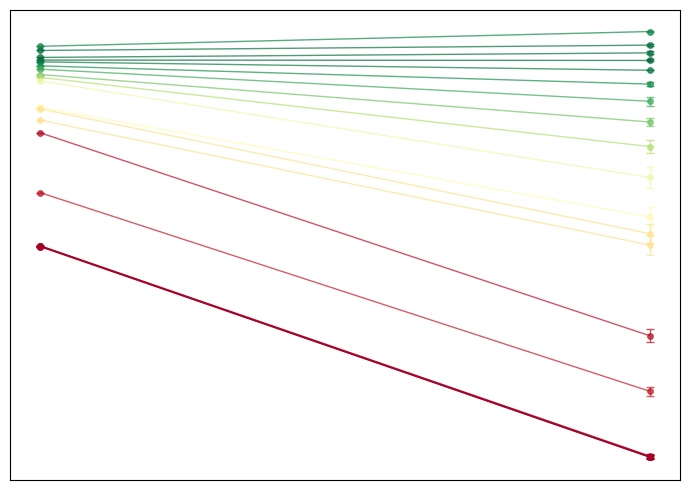

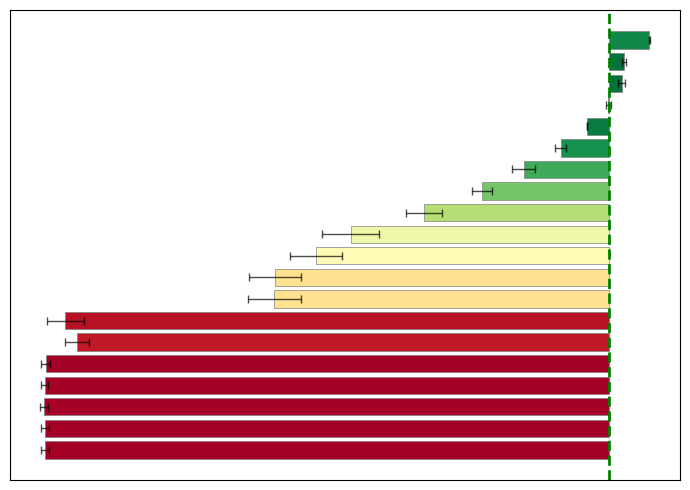

In [39]:
fig1, ax1 = plt.subplots(1, 1, figsize=(7, 5))

dts = [1/16, 2/16]
spctrums = [[spectrum_11], [spectrum_resampled]]

num_exponents = len(spctrums[0][0]["mean"])

def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        bootstrap_means.append(np.median(sample))
    lower = np.percentile(bootstrap_means, (100 - ci) / 2)
    upper = np.percentile(bootstrap_means, 100 - (100 - ci) / 2)
    return lower, upper

all_data = []
inv_dts = [1/dt for dt in dts]

for exponent_idx in range(min(num_exponents, 40)):
    exponent_values = []
    exponent_errors_lower = []
    exponent_errors_upper = []
    
    for spectrum_list in spctrums:
        all_samples = [spectrum["all_samples"][:, exponent_idx] for spectrum in spectrum_list]
        all_samples_flat = np.concatenate(all_samples)
        
        median_val = np.median(all_samples_flat)
        lower = np.percentile(all_samples_flat, 2.5)
        upper = np.percentile(all_samples_flat, 97.5)
        
        exponent_values.append(median_val)
        exponent_errors_lower.append(abs(median_val - lower))
        exponent_errors_upper.append(abs(upper - median_val))
    
    exponent_errors = [exponent_errors_lower, exponent_errors_upper]
    all_data.append({'values': exponent_values, 'errors': exponent_errors})

slopes = []
slope_errors = []
for data in all_data:
    if len(inv_dts) >= 2:
        slope = (data['values'][-1] - data['values'][0]) / (inv_dts[-1] - inv_dts[0])
        
        n_bootstrap = 4000
        bootstrap_slopes = []
        for _ in range(n_bootstrap):
            sampled_values = []
            for i, val in enumerate(data['values']):
                std_err = (data['errors'][0][i] + data['errors'][1][i]) / (2 * 1.96)
                sampled_val = np.random.normal(val, std_err)
                sampled_values.append(sampled_val)
            
            boot_slope = (sampled_values[-1] - sampled_values[0]) / (inv_dts[-1] - inv_dts[0])
            bootstrap_slopes.append(boot_slope)
        
        slope_lower = np.percentile(bootstrap_slopes, 2.5)
        slope_upper = np.percentile(bootstrap_slopes, 97.5)
        slope_error = (slope_upper - slope_lower) / 2
    else:
        slope = 0
        slope_error = 0
    
    slopes.append(slope)
    slope_errors.append(slope_error)

max_abs_slope = max(abs(s) for s in slopes) if slopes else 1
slope_colors = plt.cm.RdYlGn_r(np.abs(slopes) / max_abs_slope)

for exponent_idx, data in enumerate(all_data):
    ax1.errorbar(inv_dts, data['values'], yerr=data['errors'], marker='o', markersize=4, linewidth=1, alpha=0.7, capsize=3, color=slope_colors[exponent_idx])

ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lyapunov_spectrum_dt_scaling.svg', format='svg', transparent=True)
plt.savefig('lyapunov_spectrum_dt_scaling.pdf', format='pdf', bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(1, 1, figsize=(7, 5))

y_positions = np.arange(len(slopes))
bars = ax2.barh(y_positions, slopes, xerr=slope_errors, color=slope_colors, edgecolor='gray', linewidth=0.5, capsize=3, error_kw={'elinewidth': 1, 'alpha': 0.7})

ax2.axvline(x=0, color='green', linestyle='--', linewidth=2)

ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

In [9]:
from rc import ESN, analyse_dynamics, ESNSearchSpaceBuilder, EvaluationConfig, optimize_esn

In [10]:
space = (ESNSearchSpaceBuilder()
    .optimize("spectral_radius", bounds=(0.01, 4))  
    .optimize("alpha", bounds=(0.0001, 10), log_scale=True)
    .optimize("input_scaling", bounds=(0.01, 3))
    .optimize("bias_scaling", bounds=(0.01, 2))
    .optimize("leaky_rate", bounds=(0.01, 1))
    .fix(N=10000, mode="leaky", sparsity=0.99)
    .build())

In [11]:
config_eval = EvaluationConfig(
    washout=2000,
    warmup_steps=1000,
    predict_steps=4500,
    n_predictions=3,   
    n_instances=5,     
    metrics=['max_wasserstein'],
    wasserstein_projections=150,
    clip_wasserstein=3,
    constrain_cle=False,
)

In [168]:
import warnings
import logging

logging.getLogger('ax').setLevel(logging.ERROR)

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', module='botorch')
warnings.filterwarnings('ignore', module='gpytorch')
warnings.filterwarnings('ignore', category=RuntimeWarning, module='linear_operator')

best_params_cl, best_params_overall_cl, ax_client_cl = optimize_esn(data = worm_N2_scaled[:5, :], space = space, config = config_eval, n_trials = 50)

[INFO 02-10 21:13:16] ax.generation_strategy.dispatch_utils: Using Generators.BOTORCH_MODULAR since there is at least one ordered parameter and there are no unordered categorical parameters.
[INFO 02-10 21:13:16] ax.generation_strategy.dispatch_utils: Using Bayesian Optimization generation strategy: GenerationStrategy(name='Sobol+BoTorch', steps=[Sobol for 10 trials, BoTorch for subsequent trials]). Iterations after 10 will take longer to generate due to model-fitting.


{'spectral_radius': 2.083678352832794, 'alpha': 0.0017792345494165194, 'input_scaling': 2.9458459997177124, 'bias_scaling': 1.4038810354471207, 'leaky_rate': 0.8552232891321182}
{'max_wasserstein': (np.float64(1.326361249016414), np.float64(0.24112223725689527))}
{'spectral_radius': 0.729962412416935, 'alpha': 1.360648431933885, 'input_scaling': 0.9291188275720925, 'bias_scaling': 0.41485113465227186, 'leaky_rate': 0.019355509923771025}
{'max_wasserstein': (np.float64(3.0), np.float64(0.0))}
{'spectral_radius': 1.9046112146228553, 'alpha': 0.00010661801356170222, 'input_scaling': 2.046798616470769, 'bias_scaling': 1.7751722413487732, 'leaky_rate': 0.33178115672431885}
{'max_wasserstein': (np.float64(2.466018475389169), np.float64(0.1805871066590722))}
{'spectral_radius': 3.2938978067506106, 'alpha': 0.07361774025728661, 'input_scaling': 0.33191129513084894, 'bias_scaling': 0.7899920445587486, 'leaky_rate': 0.5506509795878083}
{'max_wasserstein': (np.float64(1.201042524347147), np.float

KeyboardInterrupt: 

In [78]:
best_params_cl = {
    'spectral_radius': 3.0142101575841567,
    'alpha': 0.0001,
    'input_scaling': 1,
    'bias_scaling': 2.0,
    'leaky_rate': 0.973170313556486
}

In [74]:
final_config = space.build_config(best_params_cl, input_dim=data.shape[0])

In [78]:
import pickle

with open('best_without_cle.pkl', 'wb') as f:
    pickle.dump(final_config, f)

In [79]:
esn_nocl = ESN(final_config)

In [80]:
esn.config

ESNConfig(N=10000, input_dim=5, spectral_radius=0.1809616855907689, alpha=1.5, sparsity=0.99, input_scaling=1.2665236214415563, bias_scaling=0.01, seed=None, weights_generation_strategy='Gaussian', bias_generation_strategy='Uniform', input_generation_strategy='Uniform', self_connections=False, dtype=dtype('float64'), mode='leaky', leaky_rate=0.7057809844406092, beta=0.5, scale=0.1)

In [81]:
esn_nocl.train(worm_N2_scaled, washout=2000)

In [89]:
predictions_nocl, states_nocl = esn_nocl.predict(warmup=worm_N2_scaled[:, 6000:8000], steps=2000)

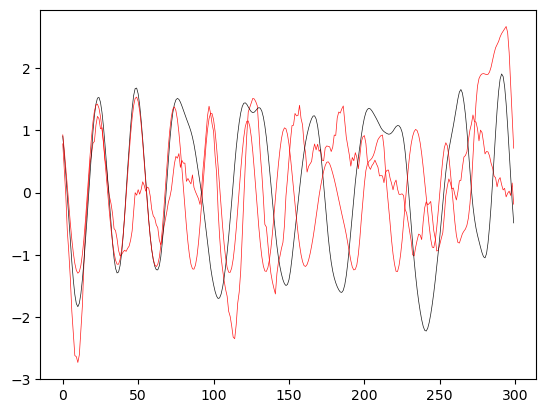

In [96]:
plt.plot(predictions_nocl[0, :300], 'red', linewidth=0.5, alpha=0.9)
plt.plot(worm_N2_scaled[0, 8000:8300], 'black', linewidth=0.5, alpha=0.9)
plt.plot(predictions_cl[0, :300], 'red', linewidth=0.5, alpha=0.9)

In [31]:
def valid_prediction_time(true_data, predictions, threshold=0.4, dt=0.01):
    """
    Compute valid prediction time before trajectory diverges.
    
    Parameters
    ----------
    true_data : ndarray of shape (D, T)
        Ground truth trajectory.
    predictions : ndarray of shape (D, T)
        Predicted trajectory.
    threshold : float, default=0.4
        Normalized squared error threshold for divergence.
    dt : float, default=0.01
        Time step for converting steps to time.
    
    Returns
    -------
    vpt : float
        Valid prediction time in time units.
    """
    variance = np.var(np.sum(true_data, axis=0))
    squared_diff = np.sum((true_data - predictions)**2, axis=0)
    normalized_error = squared_diff / variance
    
    divergence_idx = np.where(normalized_error > threshold)[0]
    valid_steps = divergence_idx[0] if len(divergence_idx) > 0 else len(normalized_error)
    
    return valid_steps * dt


In [57]:
inputdim = 5
esn = ESN(config)
esn.train(worm_N2_scaled[:inputdim, :], washout=2000)

In [107]:
warmup_data = worm_N2_scaled[:5, 6000:8000]
predictions_cl, states_cl = esn.predict(warmup_data, steps=10000)

In [97]:
import ot

In [98]:
SLW_distances_cl = []
VPTs_cl = []
SLW_distances_nocl = []
VPTs_nocl = []
for i in range(30):
    random_start = np.random.randint(0, len(worm_N2_scaled[0, :])-10000)
    data_warmup = worm_N2_scaled[:, random_start:random_start+2000]
    data_to_compare = worm_N2_scaled[:, random_start+2000:random_start+4000]
    predictions_cl, states_cl = esn.predict(data_warmup, steps=2000)
    predictions_nocl, states_nocl = esn_nocl.predict(data_warmup, steps=2000)
    # max sliced wasserstein distance
    w_dist_cl = ot.max_sliced_wasserstein_distance(data_to_compare.T, predictions_cl.T, n_projections=150)
    w_dist_nocl = ot.max_sliced_wasserstein_distance(data_to_compare.T, predictions_nocl.T, n_projections=150)
    SLW_distances_cl.append(w_dist_cl)
    SLW_distances_nocl.append(w_dist_nocl)
    VPT_cl = valid_prediction_time(data_to_compare, predictions_cl, threshold=0.4, dt=1/16)
    VPT_nocl = valid_prediction_time(data_to_compare, predictions_nocl, threshold=0.4, dt=1/16)
    VPTs_cl.append(VPT_cl)
    VPTs_nocl.append(VPT_nocl)


In [100]:
np.median(VPTs_cl), np.median(VPTs_nocl)

(np.float64(1.125), np.float64(0.4375))

In [101]:
np.median(SLW_distances_cl), np.median(SLW_distances_nocl)

(np.float64(0.49491909143485857), np.float64(0.4271725808890028))

In [104]:
lyapunov_spectrum_cl = esn.lyapunov_spectrum(worm_N2_scaled[:5, :], 20, 2500, 1, 1/16, 10, 2000, 500, False)
print("-")
lyapunov_spectrum_nocl = esn_nocl.lyapunov_spectrum(worm_N2_scaled[:5, :], 20, 2500, 1, 1/16, 10, 2000, 500, False)

-


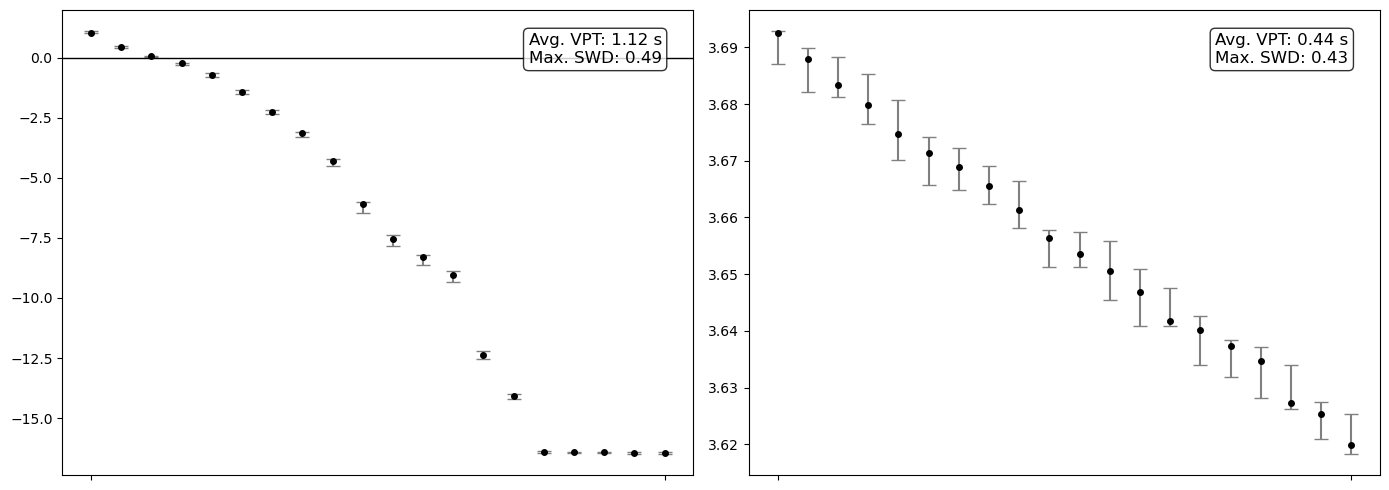

{'mean': array([3.69250456, 3.68800226, 3.68327921, 3.67984591, 3.67469575,
        3.6713128 , 3.66892363, 3.6655372 , 3.66132521, 3.65629437,
        3.65354058, 3.65052155, 3.64685777, 3.64173483, 3.64011875,
        3.63725724, 3.63462845, 3.62735051, 3.62530957, 3.61983561]),
 'std': array([0.00513546, 0.00487833, 0.0044711 , 0.00475007, 0.00497846,
        0.00535802, 0.00478707, 0.00430716, 0.00441798, 0.00425334,
        0.00454179, 0.00568674, 0.00570401, 0.00447353, 0.00519588,
        0.00546855, 0.00483054, 0.0040329 , 0.00411906, 0.00401721]),
 'all_samples': array([[3.69831152, 3.68440803, 3.68757577, 3.68674683, 3.66943093,
         3.67283913, 3.67170738, 3.67027638, 3.6676883 , 3.6589156 ,
         3.66506143, 3.65479319, 3.64354867, 3.65227612, 3.64438966,
         3.64074207, 3.62632972, 3.62643695, 3.63112724, 3.62426795],
        [3.68842875, 3.69092853, 3.67655238, 3.68245249, 3.67859748,
         3.67477477, 3.66731846, 3.66370268, 3.66483744, 3.64681466,
       

In [115]:
# Plot both Lyapunov spectrums
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot spectrum with closed loop
means_cl = lyapunov_spectrum_cl['mean']
n_bootstraps = 1000
bootstrap_medians_cl = []
if 'all_samples' in lyapunov_spectrum_cl:
    samples_cl = lyapunov_spectrum_cl['all_samples']
    for _ in range(n_bootstraps):
        resample_idxs = np.random.choice(len(samples_cl), len(samples_cl), replace=True)
        resample = samples_cl[resample_idxs]
        bootstrap_medians_cl.append(np.mean(resample, axis=0))
    bootstrap_medians_cl = np.array(bootstrap_medians_cl)
    ci_lower_cl = np.percentile(bootstrap_medians_cl, 2.5, axis=0)
    ci_upper_cl = np.percentile(bootstrap_medians_cl, 97.5, axis=0)
    yerr_cl = np.array([means_cl - ci_lower_cl, ci_upper_cl - means_cl])
    # Ensure no negative values in yerr
    yerr_cl = np.abs(yerr_cl)
else:
    yerr_cl = lyapunov_spectrum_cl['std']

ax1.errorbar(
    range(1, len(means_cl) + 1),
    means_cl,
    yerr=yerr_cl,
    fmt='k.',
    ms=8,
    capsize=5,
    ecolor='gray'
)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax1.set_xticks([1, len(means_cl)])
ax1.set_xticklabels(['', ''])
ax1.minorticks_off()
ax1.text(0.95, 0.95, f'Avg. VPT: {np.median(VPTs_cl):.2f} s\nMax. SWD: {np.median(SLW_distances_cl):.2f}',
         transform=ax1.transAxes, verticalalignment='top', horizontalalignment='right',
         fontsize=12,
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.8))

# Plot spectrum without closed loop
means_nocl = lyapunov_spectrum_nocl['mean']
bootstrap_medians_nocl = []
if 'all_samples' in lyapunov_spectrum_nocl:
    samples_nocl = lyapunov_spectrum_nocl['all_samples']
    for _ in range(n_bootstraps):
        resample_idxs = np.random.choice(len(samples_nocl), len(samples_nocl), replace=True)
        resample = samples_nocl[resample_idxs]
        bootstrap_medians_nocl.append(np.mean(resample, axis=0))
    bootstrap_medians_nocl = np.array(bootstrap_medians_nocl)
    ci_lower_nocl = np.percentile(bootstrap_medians_nocl, 2.5, axis=0)
    ci_upper_nocl = np.percentile(bootstrap_medians_nocl, 97.5, axis=0)
    yerr_nocl = np.array([means_nocl - ci_lower_nocl, ci_upper_nocl - means_nocl])
    # Ensure no negative values in yerr
    yerr_nocl = np.abs(yerr_nocl)
else:
    yerr_nocl = lyapunov_spectrum_nocl['std']

ax2.errorbar(
    range(1, len(means_nocl) + 1),
    means_nocl,
    yerr=yerr_nocl,
    fmt='k.',
    ms=8,
    capsize=5,
    ecolor='gray'
)
# ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xticks([1, len(means_nocl)])
ax2.set_xticklabels(['', ''])
ax2.minorticks_off()
ax2.text(0.95, 0.95, f'Avg. VPT: {np.median(VPTs_nocl):.2f} s\nMax. SWD: {np.median(SLW_distances_nocl):.2f}',
         transform=ax2.transAxes, verticalalignment='top', horizontalalignment='right',
         fontsize=12,
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.8))

plt.tight_layout()
plt.savefig('lyapunov_spectrum_cl_nocl.svg', format='svg', transparent=True)
plt.savefig('lyapunov_spectrum_cl_nocl.pdf', format='pdf', bbox_inches='tight')
plt.show()

lyapunov_spectrum_nocl

In [105]:
lyapunov_spectrum_cl

{'mean': array([  1.04837059,   0.45126608,   0.06403392,  -0.20702356,
         -0.71474149,  -1.41789118,  -2.23924649,  -3.15001643,
         -4.30220919,  -6.09587485,  -7.54352662,  -8.29634088,
         -9.04012043, -12.36978423, -14.07013026, -16.40258879,
        -16.41780141, -16.42780413, -16.43690216, -16.44524842]),
 'std': array([0.07302078, 0.05758239, 0.03590816, 0.07995204, 0.10898677,
        0.12398259, 0.14878384, 0.17345613, 0.21760608, 0.39994592,
        0.3924959 , 0.34828439, 0.36605219, 0.26877311, 0.19396501,
        0.05839569, 0.05354158, 0.05593217, 0.05682912, 0.05856808]),
 'all_samples': array([[  1.01320995,   0.3886082 ,   0.03391135,  -0.22059655,
          -0.78513617,  -1.50719609,  -2.24498458,  -3.29825058,
          -4.59133315,  -6.09738306,  -7.56800423,  -8.31046301,
          -9.00991736, -12.4151252 , -14.17736199, -16.38995444,
         -16.42062221, -16.43985937, -16.44524945, -16.46178437],
        [  1.11520295,   0.53916954,   0.1361398

In [ ]:
plt.plot(predictions_cl[0, :], predictions_cl[1, :], 'black', linewidth=0.5, alpha=0.9)

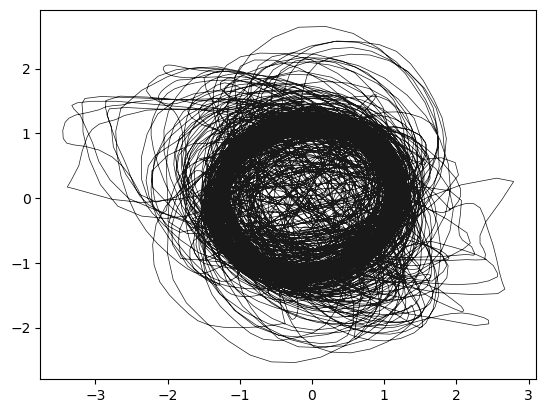

In [108]:
plt.plot(predictions_cl[0, :], predictions_cl[1, :], 'black', linewidth=0.5, alpha=0.9)
plt.show()

In [62]:
valid_prediction_times = valid_prediction_time(worm_N2_scaled[:, 8000:10000], predictions_cl, threshold=0.4, dt=1/16)

In [92]:
valid_prediction_times_nocl = valid_prediction_time(worm_N2_scaled[:, 8000:10000], predictions_nocl, threshold=0.4, dt=1/16)
valid_prediction_times = valid_prediction_time(worm_N2_scaled[:, 8000:10000], predictions_cl, threshold=0.4, dt=1/16)

In [93]:
valid_prediction_times, valid_prediction_times_nocl

(np.float64(4.9375), np.float64(0.875))

In [147]:
result2 = esn.conditional_lyapunov_spectrum(
    data=worm_N2_scaled[:, :],  
    num_lyaps=1,
    norm_time=2,
    dt=1/16,
    warmup=1000,
    transient=1500,
)


In [151]:
result2

{'exponents': array([-1.50045262]),
 'convergence': None,
 'max_cle': np.float64(-1.5004526161825424),
 'sum_cle': np.float64(-1.5004526161825424),
 'num_renorms': 13685}

In [149]:
spectrum2 = esn.lyapunov_spectrum(worm_N2_scaled[:, :], 40, 2500, 1, 1/16, 10, 2000, 500, False)

In [ ]:
num_experiments = 20
for i in range(num_experiments):
    spectrum = esn.lyapunov_spectrum(worm_N2_scaled[:, :], 40, 2500, 1, 1/16, 10, 2000, 500, False)

In [76]:
spectrum

{'mean': array([0.56620923, 0.55069298, 0.53795538, 0.52393597, 0.50603283,
        0.49347947, 0.48802227, 0.47189659, 0.4672057 , 0.45624157,
        0.43435945, 0.4281606 , 0.41649423, 0.39490999, 0.38873144,
        0.37411582, 0.35983058, 0.35632745, 0.33899697, 0.32298134,
        0.31708494, 0.30879941, 0.2891217 , 0.28055512, 0.26809358,
        0.24857757, 0.23940381, 0.22437153, 0.21648785, 0.20911817,
        0.1963154 , 0.18455635, 0.17455506, 0.15263193, 0.15013083,
        0.13827727, 0.123254  , 0.1096836 , 0.09992267, 0.09058499]),
 'std': array([0.00838269, 0.0072311 , 0.00757128, 0.00329796, 0.00684582,
        0.00556468, 0.00342849, 0.00710544, 0.00903928, 0.00644522,
        0.00398369, 0.00574843, 0.00971921, 0.0066264 , 0.00263749,
        0.00482187, 0.00268736, 0.00615968, 0.00479464, 0.0027243 ,
        0.00230521, 0.0074563 , 0.00318128, 0.00618799, 0.00295029,
        0.00316222, 0.00430557, 0.00656861, 0.00511732, 0.00449739,
        0.00607972, 0.00791054,

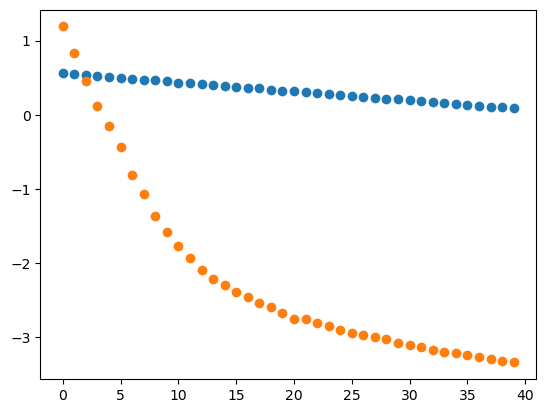

In [150]:
plt.plot(spectrum["mean"], 'o')
plt.plot(spectrum2["mean"], 'o')
plt.show()

In [11]:
inputdim = 5
esn_wrong = ESN(config)
esn_wrong.train(worm_N2_scaled[:inputdim, :], washout=2000)

In [13]:
warmup_data = worm_N2_scaled[:inputdim, 2000:4000]
predictions, states = esn_wrong.predict(warmup_data, steps=10000)

In [69]:
read_data_slice = worm_N2_scaled[:5, 4000:14000]

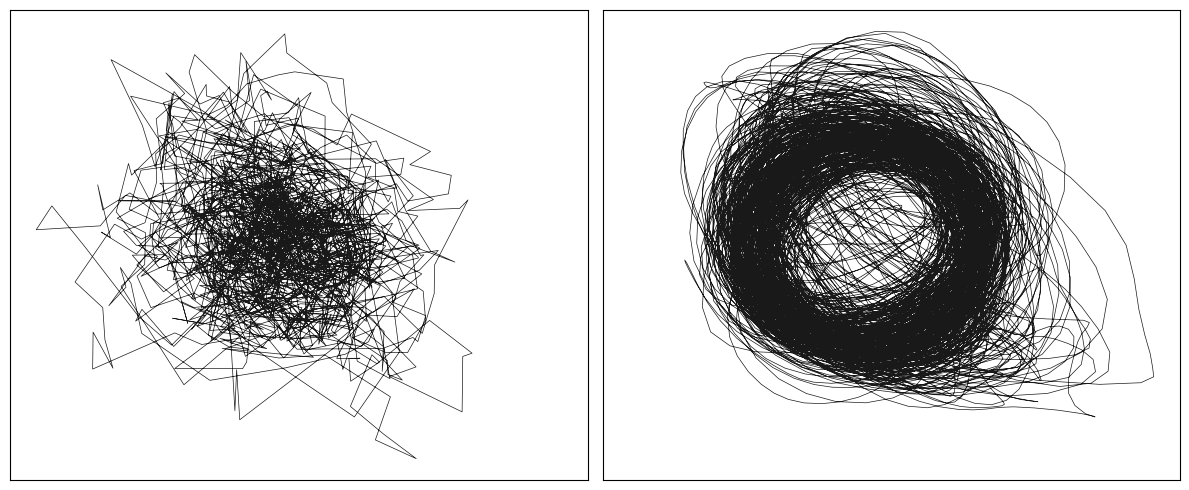

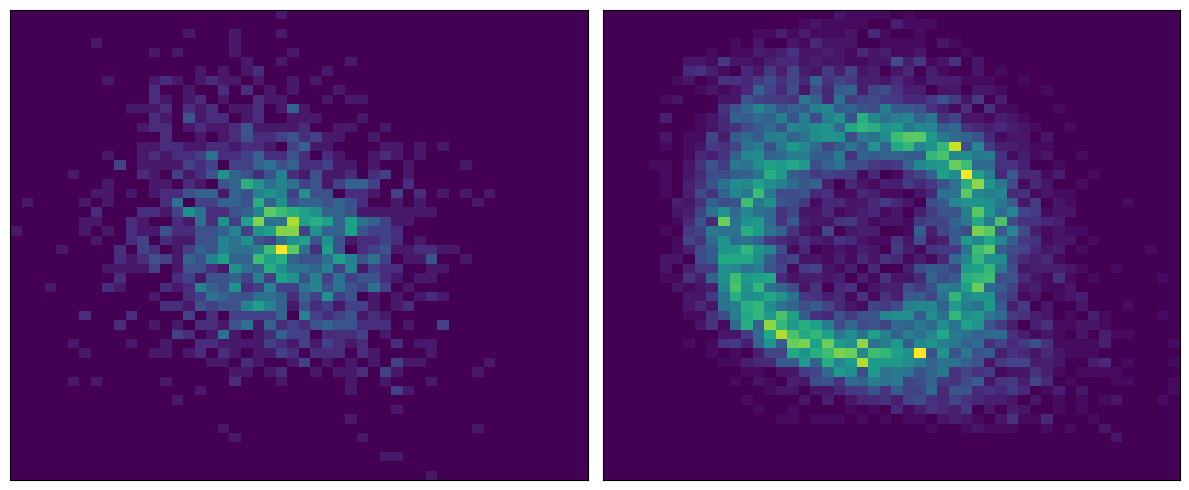

In [70]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_min = min(predictions[0, :].min(), read_data_slice[0, :].min())
x_max = max(predictions[0, :].max(), read_data_slice[0, :].max())
y_min = min(predictions[1, :].min(), read_data_slice[1, :].min())
y_max = max(predictions[1, :].max(), read_data_slice[1, :].max())

x_padding = (x_max - x_min) * 0.05
y_padding = (y_max - y_min) * 0.05

ax1.plot(predictions[0, :], predictions[1, :], 'black', linewidth=0.5, alpha=0.9)

ax1.set_xlim(x_min - x_padding, x_max + x_padding)
ax1.set_ylim(y_min - y_padding, y_max + y_padding)
ax1.set_xticks([])
ax1.set_yticks([])

ax2.plot(read_data_slice[0, :], read_data_slice[1, :], 'black', linewidth=0.5, alpha=0.9)

ax2.set_xlim(x_min - x_padding, x_max + x_padding)
ax2.set_ylim(y_min - y_padding, y_max + y_padding)
ax2.set_xticks([])
ax2.set_yticks([])

plt.tight_layout()
# plt.savefig('prediction_vs_real.svg', format='svg', transparent=True)
# plt.savefig('prediction_vs_real.pdf', format='pdf', bbox_inches='tight')
plt.show()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_min = min(predictions[0, :].min(), read_data_slice[0, :].min())
x_max = max(predictions[0, :].max(), read_data_slice[0, :].max())
y_min = min(predictions[1, :].min(), read_data_slice[1, :].min())
y_max = max(predictions[1, :].max(), read_data_slice[1, :].max())

ax1.hist2d(predictions[0, :], predictions[1, :], bins=50, range=[[x_min, x_max], [y_min, y_max]])
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.set_xticks([])
ax1.set_yticks([])

ax2.hist2d(read_data_slice[0, :], read_data_slice[1, :], bins=50, range=[[x_min, x_max], [y_min, y_max]])
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.set_xticks([])
ax2.set_yticks([])

plt.tight_layout()
# plt.savefig('histogram_prediction.svg', format='svg', transparent=True)
# plt.savefig('histogram_real.svg', format='svg', transparent=True)
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

  # -------- loading --------
ROOT = Path("/Users/iliasoroka/RC_esn")
WORM = 1


worm 1: 20 trajectory samples × 20 exponents
observed best ESN: esn_3


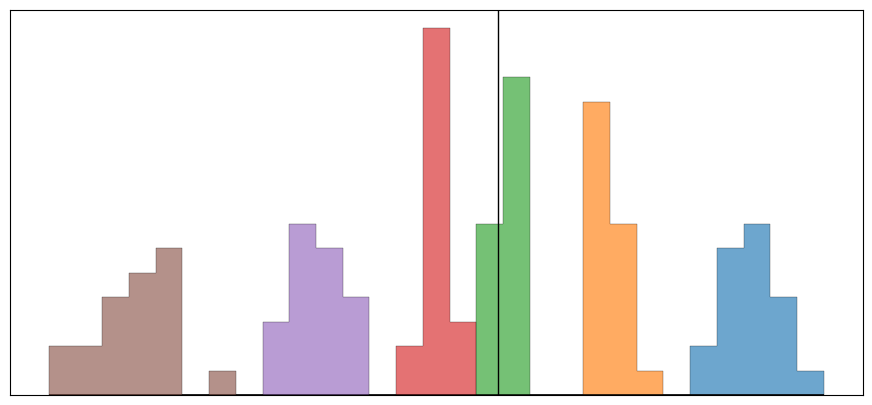

λ_1: median=+0.910  95% CI=[+0.772, +1.117]  n=20
λ_2: median=+0.395  95% CI=[+0.317, +0.501]  n=20
λ_3: median=+0.036  95% CI=[-0.037, +0.105]  n=20
λ_4: median=-0.233  95% CI=[-0.308, -0.137]  n=20
λ_5: median=-0.672  95% CI=[-0.817, -0.491]  n=20
λ_6: median=-1.304  95% CI=[-1.606, -1.065]  n=20


In [ ]:

d = np.load(ROOT / f"esns/worm_{WORM}/lyap_best.npz")
# all_samples: (20, 20) — 20 trajectory samples × 20 Lyapunov exponents
all_samples = d["all_samples"]

# Sort each sample descending so column i corresponds to λ_{i+1}
samples = np.sort(all_samples, axis=1)[:, ::-1]
print(f"worm {WORM}: {samples.shape[0]} trajectory samples × {samples.shape[1]} exponents")
print(f"observed best ESN: esn_{int(d['esn_idx'])}")

# -------- plot --------
N_SHOW = 6
N_BINS = 30  # 20 samples only — don't go too high or it'll be spiky
COLOURS = plt.get_cmap("tab10").colors[:N_SHOW]

top = samples[:, :N_SHOW]
xmin, xmax = top.min(), top.max()
bins = np.linspace(xmin, xmax, N_BINS)

fig, ax = plt.subplots(figsize=(11, 5))
for i in range(N_SHOW):
    ax.hist(top[:, i], bins=bins, alpha=0.65, density=True,
            color=COLOURS[i], histtype="stepfilled",
            edgecolor="black", linewidth=0.3,
            label=f"λ_{i+1}")
ax.axvline(0, color="black", linestyle="-", linewidth=1)
ax.set_xticks([])
ax.set_yticks([])
ax.minorticks_off()
# ax.legend()   # uncomment if you want labels during exploration
plt.show()

# -------- per-exponent numeric summary --------
for i in range(N_SHOW):
    v = top[:, i]
    med = np.median(v)
    lo, hi = np.quantile(v, [0.025, 0.975])
    print(f"λ_{i+1}: median={med:+.3f}  95% CI=[{lo:+.3f}, {hi:+.3f}]  n={len(v)}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

  # -------- loading --------
ROOT = Path("/Users/iliasoroka/RC_esn")
WORM = 1
rng = np.random.default_rng(42)
n_boot = 1000
boot_medians = np.array([
      np.median(samples[rng.integers(0, len(samples),
  size=len(samples))], axis=0)
      for _ in range(n_boot)
  ])
  # shape: (1000, 20)

for i in range(6):
      v = boot_medians[:, i]
      med = np.median(v)
      lo, hi = np.percentile(v, [2.5, 97.5])
      lo, hi = np.percentile(v, [2.5, 97.5])
      raw = samples[:, i]
      raw_lo, raw_hi = np.quantile(raw, [0.025, 0.975])
      print(f"λ_{i+1}: median={med:+.3f}  "
            f"bootstrap-median CI=[{lo:+.3f}, {hi:+.3f}]  "
            f"raw-sample 95%=[{raw_lo:+.3f}, {raw_hi:+.3f}]")

λ_1: median=+0.910  bootstrap-median CI=[+0.874, +0.940]  raw-sample 95%=[+0.772, +1.117]
λ_2: median=+0.395  bootstrap-median CI=[+0.357, +0.436]  raw-sample 95%=[+0.317, +0.501]
λ_3: median=+0.036  bootstrap-median CI=[+0.005, +0.083]  raw-sample 95%=[-0.037, +0.105]
λ_4: median=-0.233  bootstrap-median CI=[-0.245, -0.201]  raw-sample 95%=[-0.308, -0.137]
λ_5: median=-0.672  bootstrap-median CI=[-0.713, -0.618]  raw-sample 95%=[-0.817, -0.491]
λ_6: median=-1.304  bootstrap-median CI=[-1.348, -1.204]  raw-sample 95%=[-1.606, -1.065]


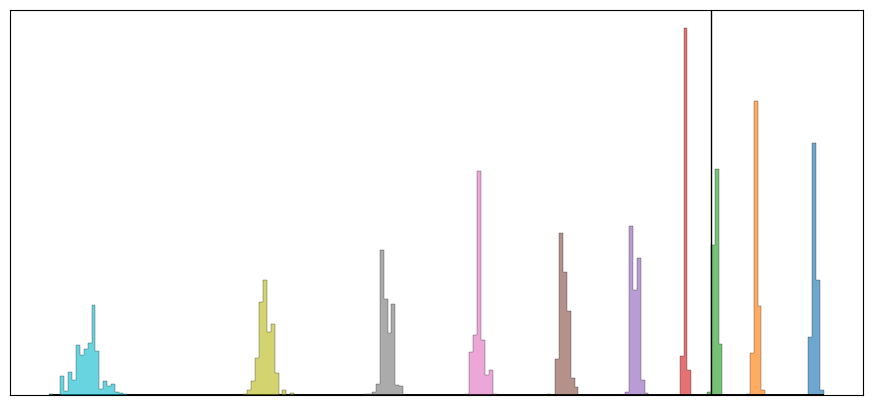

In [11]:
import matplotlib.pyplot as plt

N_SHOW = 10
N_BINS = 200

top = boot_medians[:, :N_SHOW]  # (1000, 6)
COLOURS = plt.get_cmap("tab10").colors[:N_SHOW]

xmin, xmax = top.min(), top.max()
bins = np.linspace(xmin, xmax, N_BINS)

fig, ax = plt.subplots(figsize=(11, 5))
for i in range(N_SHOW):
    ax.hist(
        top[:, i], bins=bins, alpha=0.65, density=True,
        color=COLOURS[i], histtype="stepfilled",
        edgecolor="black", linewidth=0.3, label=f"λ_{i+1}",
    )
ax.axvline(0, color="black", linestyle="-", linewidth=1)
ax.set_xticks([])
ax.set_yticks([])
ax.minorticks_off()
# ax.legend()     # uncomment while exploring
plt.show()

In [6]:
for i in range(N_SHOW):
    ax.hist(top[:, i], bins=bins, alpha=0.65, density=True,
            color=COLOURS[i], histtype="stepfilled",
            edgecolor="black", linewidth=0.3,
            label=f"λ_{i+1}")
ax.axvline(0, color="black", linestyle="-", linewidth=1)
ax.set_xticks([])
ax.set_yticks([])
ax.minorticks_off()
# ax.legend()   # uncomment if you want labels during exploration
plt.show()
